# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 609kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.20MB/s]


In [2]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


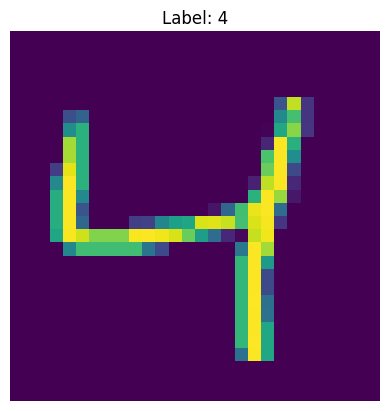

In [3]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [4]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [5]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: input_dim → hidden_dim
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: hidden_dim → hidden_dim
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수)
        self.tanh2 = nn.Tanh()

        # Linear function 3: hidden_dim → hidden_dim
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: hidden_dim → output_dim
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4 (마지막 출력층)
        out = self.fc4(out)
        return out


In [6]:
# ANN 객체 생성
input_dim = 28*28   # 이미지 크기 (28x28)
hidden_dim = 150    # 하이퍼파라미터 (150으로 설정)
output_dim = 5      # 출력 클래스 개수 (0~4)

model = ANNModel(input_dim, hidden_dim, output_dim)

# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


#### **ANN 모델 학습**

In [7]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []        # Loss 저장 리스트
iteration_list = []   # Iteration 저장 리스트
accuracy_list = []    # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)   # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels                  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.18396268784999847  Accuracy: 96.53629302978516 %
Iteration: 1000  Loss: 0.10607526451349258  Accuracy: 97.33411407470703 %
Iteration: 1500  Loss: 0.11651469767093658  Accuracy: 97.60653686523438 %
Iteration: 2000  Loss: 0.22533680498600006  Accuracy: 97.74275207519531 %
Iteration: 2500  Loss: 0.04765433445572853  Accuracy: 97.99571990966797 %
Iteration: 3000  Loss: 0.02274635061621666  Accuracy: 98.01517486572266 %
Iteration: 3500  Loss: 0.2693204879760742  Accuracy: 98.28760528564453 %
Iteration: 4000  Loss: 0.0383891686797142  Accuracy: 98.46273803710938 %
Iteration: 4500  Loss: 0.04719161614775658  Accuracy: 98.50165557861328 %


#### **ANN 학습 결과**

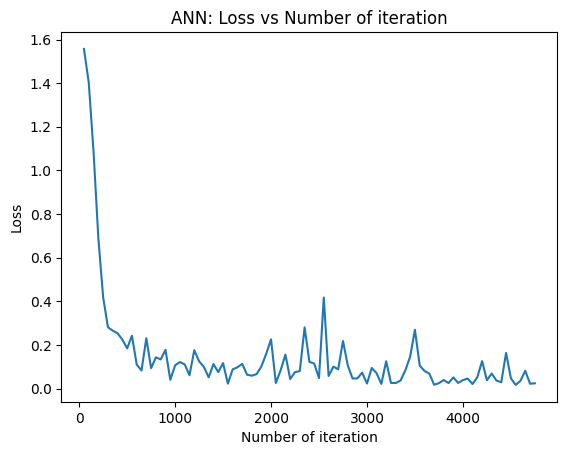

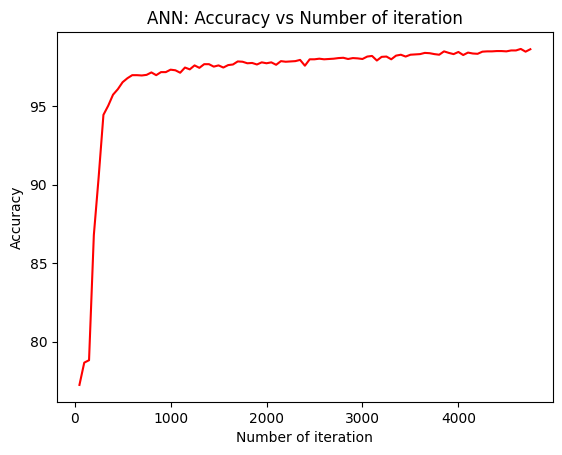

In [8]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**

-초기 Loss 값이 약 1.6 정도로 시작 → 학습이 진행되면서 급격히 감소
→ 모델이 처음에는 예측을 잘 못했지만, 학습하면서 점차 데이터의 패턴을 학습했다는 뜻입니다.

-Iteration 500 이후부터는 Loss 값이 0.2 이하에서 안정화
→ 학습률이 적절하고, 모델이 수렴하고 있다는 의미입니다.
→ 큰 폭의 감소가 멈추고 작은 변동만 있는 건 정상적인 패턴입니다.

-중간중간 Loss 값이 튀는 구간이 있음
→ 미니배치(batch)마다 데이터가 다르기 때문에 발생하는 자연스러운 현상입니다.
→ 전체적인 추세가 하강 곡선을 유지한다면 문제가 되지 않습니다.

-거의 0에 가까운 Loss 도달
→ 모델이 훈련 데이터에 대해 매우 높은 적합도를 보이는 상태입니다.
→ 다만 이 경우 overfitting(과적합) 가능성도 있기 때문에, 반드시 테스트 정확도(Accuracy) 그래프도 같이 봐야 합니다.


#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [9]:
# 실험 1 hidden_dims=[50, 100, 150, 200] 로 학습
hidden_dims = [50, 100, 150, 200]
results = {}

for h in hidden_dims:
    model = ANNModel(input_dim, h, output_dim)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.02)

    loss_list = []
    accuracy_list = []

    # 간단히 epoch=1~2 정도만 돌려서 비교
    for epoch in range(2):
        for images, labels in train_loader:
            train = images.view(-1, 28*28)
            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

        # 정확도 측정
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                test = images.view(-1, 28*28)
                outputs = model(test)
                predicted = torch.max(outputs.data, 1)[1]
                total += len(labels)
                correct += (predicted == labels).sum().item()
        accuracy = 100 * correct / total
        loss_list.append(loss.item())
        accuracy_list.append(accuracy)

    results[h] = (loss_list, accuracy_list)


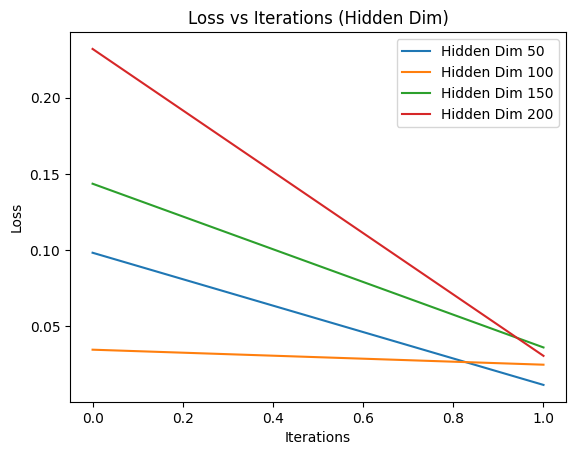

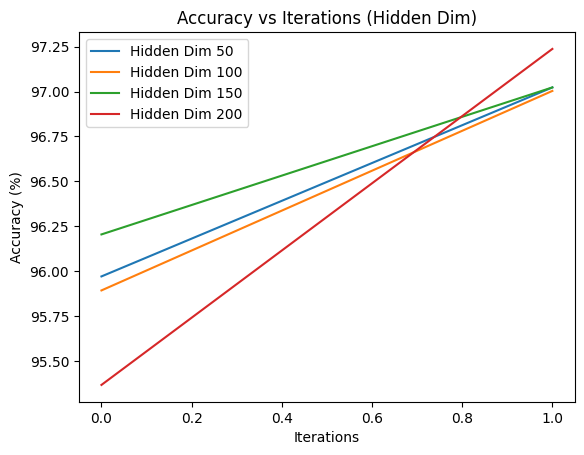

In [10]:
# 실험 1 모델 학습 결과 시각화
for h in hidden_dims:
    plt.plot(results[h][0], label=f'Hidden Dim {h}')
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations (Hidden Dim)")
plt.legend()
plt.show()

for h in hidden_dims:
    plt.plot(results[h][1], label=f'Hidden Dim {h}')
plt.xlabel("Iterations")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Iterations (Hidden Dim)")
plt.legend()
plt.show()


**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**

1. Loss vs Iterations (위 그래프)

Hidden Dim이 클수록 초기 손실(Loss)이 더 큼 → 파라미터가 많아지면서 학습 초반엔 불안정할 수 있음.

하지만 Iteration이 진행될수록 모든 hidden_dim이 손실을 안정적으로 줄임.

Hidden Dim이 작은 경우(50, 100)는 초반 손실이 낮고 안정적, 큰 경우(200)는 초반 손실이 크지만 빠르게 감소.

 즉, Hidden Dim이 클수록 학습 난이도는 조금 올라가지만, 충분히 학습하면 오히려 더 낮은 손실에 도달할 수 있음.


2. Accuracy vs Iterations (아래 그래프)

모든 hidden_dim 값이 96~97% 수준의 높은 정확도로 수렴.

Hidden Dim=200 모델은 초반 정확도가 낮지만, 학습이 진행되면서 다른 모델보다 빠르게 성능이 개선됨.

Hidden Dim=50, 100은 상대적으로 안정적이지만 큰 성능 차이는 없음.

결국 충분한 학습 시간이 주어지면 Hidden Dim 크기에 관계없이 비슷한 정확도에 도달하지만,
큰 Hidden Dim은 더 복잡한 패턴을 학습할 수 있는 잠재력이 있음.

In [11]:
# 실험 2 learning_rates=[0.1, 0.05, 0.02, 0.005] 로 학습
learning_rates = [0.1, 0.05, 0.02, 0.005]
results_lr = {}

for lr in learning_rates:
    model = ANNModel(input_dim, hidden_dim, output_dim)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    loss_list = []
    accuracy_list = []

    for epoch in range(2):   # 간단히 epoch=2 정도만 돌려서 비교
        for images, labels in train_loader:
            train = images.view(-1, 28*28)
            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

        # 정확도 측정
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                test = images.view(-1, 28*28)
                outputs = model(test)
                predicted = torch.max(outputs.data, 1)[1]
                total += len(labels)
                correct += (predicted == labels).sum().item()
        accuracy = 100 * correct / total
        loss_list.append(loss.item())
        accuracy_list.append(accuracy)

    results_lr[lr] = (loss_list, accuracy_list)


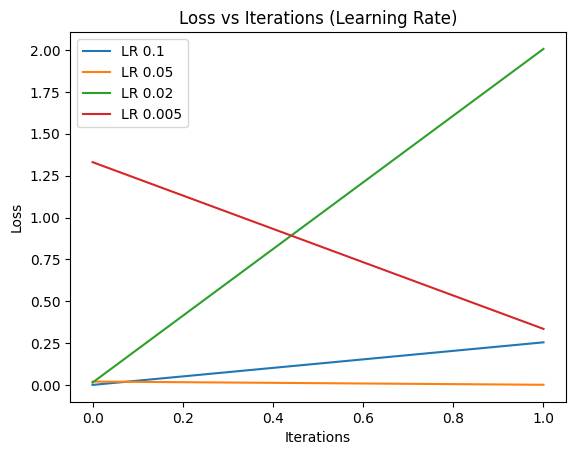

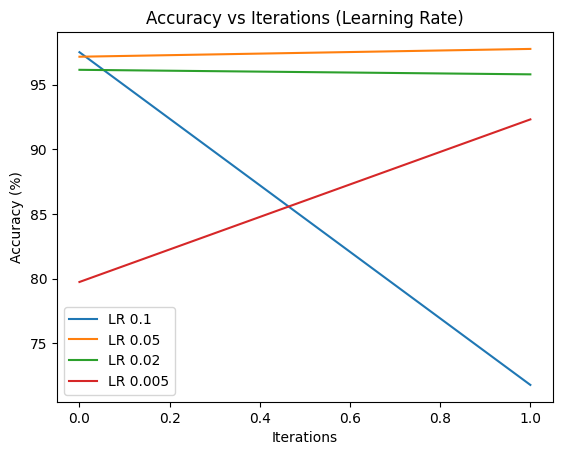

In [12]:
# 실험 2 모델 학습 결과 시각화 (Loss)
for lr in learning_rates:
    plt.plot(results_lr[lr][0], label=f'LR {lr}')
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations (Learning Rate)")
plt.legend()
plt.show()

# 실험 2 모델 학습 결과 시각화 (Accuracy)
for lr in learning_rates:
    plt.plot(results_lr[lr][1], label=f'LR {lr}')
plt.xlabel("Iterations")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Iterations (Learning Rate)")
plt.legend()
plt.show()


**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**

1. Loss vs Iterations

LR=0.1 (파랑): Loss가 줄지 않고 오히려 오락가락 → 학습률이 너무 커서 발산하거나 최적점을 지나치고 있음.

LR=0.05 (주황): Loss가 가장 안정적으로 줄어들고, 거의 0에 근접 → 가장 적절한 학습률.

LR=0.02 (초록): Loss가 줄지 않고 오히려 증가 → 학습률 설정이 불안정.

LR=0.005 (빨강): Loss가 천천히 줄긴 하지만 속도가 매우 느림.


2. Accuracy vs Iterations (오른쪽 그래프)

LR=0.1: Accuracy가 오히려 감소 → 모델이 불안정하게 학습.

LR=0.05: Accuracy가 가장 빠르고 안정적으로 높아짐 → 최적 학습률.

LR=0.02: Accuracy가 개선되지 않고 정체 → 수렴이 잘 안 됨.

LR=0.005: Accuracy가 천천히 오르지만 다른 학습률보다 느림.


결론

학습률이 너무 크면(LR=0.1) → Loss 발산, Accuracy 저하 → 학습 불안정.

학습률이 너무 작으면(LR=0.005) → Loss는 줄지만 속도가 너무 느림.

**중간값(LR=0.05)**이 가장 안정적이고 빠른 수렴을 보여 최적의 Learning Rate로 판단됨.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # Fully Connected Layer
        # Conv → Pooling을 거친 뒤 feature map 크기 계산:
        # 입력: 28x28 → Conv1(5x5) → 24x24 → Pool1(2x2) → 12x12
        # → Conv2(5x5) → 8x8 → Pool2(2x2) → 4x4
        # 최종 feature map 크기: 32채널 × 4 × 4 = 512
        self.fc1 = nn.Linear(32*4*4, 10)  # 입력 512, 출력 클래스 개수 10

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게 변환
        out = out.view(-1, 32*4*4)

        # 완전 연결 계층
        out = self.fc1(out)
        return out


In [14]:
# CNN 객체 생성
model = CNNModel()

# 손실 함수 설정 (다중분류 → CrossEntropyLoss)
loss_ftn = nn.CrossEntropyLoss()

# SGD Optimizer 사용
learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)


#### **CNN 모델 학습**

In [15]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []        # Loss 저장 리스트
iteration_list = []   # Iteration 저장 리스트
accuracy_list = []    # 정확도 저장 리스트
num_epochs = 20       # 학습할 epoch 수

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스를 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.48588341526640483
Epoch 2, Loss: 0.12909926444152078
Epoch 3, Loss: 0.1057417684337727
Epoch 4, Loss: 0.09045194306397239
Epoch 5, Loss: 0.07850220707674863
Epoch 6, Loss: 0.06913201417664595
Epoch 7, Loss: 0.06134221703105748
Epoch 8, Loss: 0.05550868747297029
Epoch 9, Loss: 0.05015106932775337
Epoch 10, Loss: 0.046081803662270805
Epoch 11, Loss: 0.04255020873385845
Epoch 12, Loss: 0.03932162545338742
Epoch 13, Loss: 0.03709007298948373
Epoch 14, Loss: 0.03536010518648695
Epoch 15, Loss: 0.03349085128623098
Epoch 16, Loss: 0.03163255166109517
Epoch 17, Loss: 0.029921655342885
Epoch 18, Loss: 0.02917247738529751
Epoch 19, Loss: 0.02804199727161594
Epoch 20, Loss: 0.026894835287380365


#### **CNN 학습 결과**

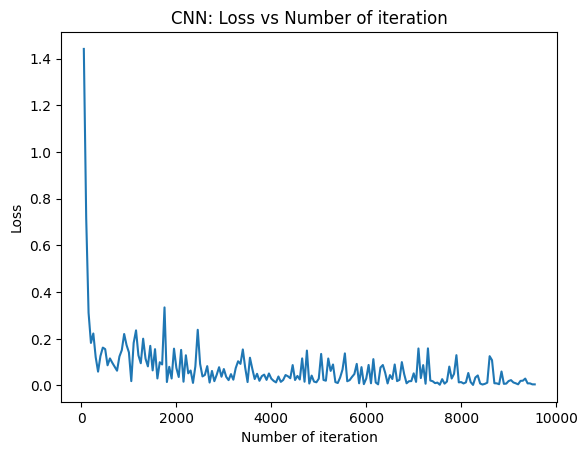

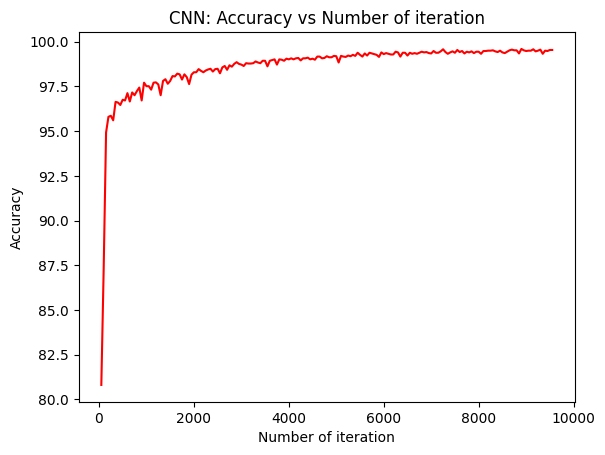

In [16]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**

-ANN (Artificial Neural Network)

구조: 입력층(Input) → 여러 개의 은닉층(Hidden layer, Fully Connected Layer) → 출력층(Output).

특징:

모든 뉴런이 완전 연결되어 있어 이미지 같은 2차원 데이터의 공간적 구조를 직접 반영하지 못함.

Flatten된 벡터(28×28 → 784차원) 형태로 학습.

결과 (MNIST):

손실(Loss)은 서서히 감소, 정확도(Accuracy)는 95~97% 부근까지 도달.

이미지의 공간 구조를 직접 학습하지 못해 CNN보다 성능이 다소 낮음.


-CNN (Convolutional Neural Network)

구조: 합성곱 계층(Convolution) + 풀링(Pooling) → 여러 층 반복 → 완전 연결층(FC).

특징:

이미지의 **공간적 특징(패턴, 모서리, 텍스처)**을 필터로 자동 추출.

파라미터 수가 ANN보다 적으면서도 이미지 분류에 특화.

결과 (MNIST):

손실이 빠르게 감소 후 0에 수렴.

정확도는 학습이 진행되면서 99% 가까이 도달.

ANN보다 훨씬 높은 성능과 빠른 수렴 속도를 보여줌.


-> ANN은 단순한 구조로도 MNIST를 어느 정도 잘 학습하지만, 이미지의 공간 구조를 활용하지 못해 성능 한계가 있음.

CNN은 합성곱 필터를 통해 이미지의 국소적 특징을 추출하기 때문에, 손실이 더 빨리 줄고 정확도도 더 높게 나옴.